# Задача 2. Регрессия CC50

**Цель:** предсказать концентрацию, при которой соединение убивает 50% клеток хозяина, то есть меру его цитотоксичности
Чем выше CC50, тем безопаснее вещество. Ранняя оценка токсичности особенно ценна, поскольку именно неприемлемая токсичность частая причина провала кандидатов на поздних стадиях разработки

Как и для IC50, обучение ведётся на log10(CC50) исходная асимметрия 1.97, эксцесс 5.68

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append(str(Path.cwd().parent))
from src import data_utils as du  # noqa: E402
from src import modeling as mdl  # noqa: E402

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

FIG_DIR = Path.cwd().parent / "reports" / "figures"
RES_DIR = Path.cwd().parent / "results"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Загрузка данных

In [2]:
features, targets, groups, clean_report = du.load_dataset()
target = targets["log_cc50"]

print(f"Признаков: {features.shape[1]}, объектов: {features.shape[0]}")
print(f"Уникальных молекул (групп): {len(np.unique(groups))}")
print(f"\nЦелевая переменная: log10(CC50, mM)")
print(target.describe().round(3).to_string())

Признаков: 178, объектов: 1001
Уникальных молекул (групп): 804

Целевая переменная: log10(CC50, mM)
count    1001.000
mean        2.407
std         0.716
min        -0.154
25%         2.000
50%         2.614
75%         2.951
max         3.657


## 2. Разбиение на обучение и отложенный тест


In [3]:
X_train, X_test, y_train, y_test, groups_train = mdl.group_train_test_split(
    features, target, groups
)
train_groups = set(groups[np.isin(features.index, X_train.index)])
test_groups = set(groups[np.isin(features.index, X_test.index)])

print(f"train: {X_train.shape[0]} объектов, {len(train_groups)} групп")
print(f"test:  {X_test.shape[0]} объектов, {len(test_groups)} групп")
print(f"Пересечение групп train/test: {len(train_groups & test_groups)}")

display(pd.DataFrame({
    "train": y_train.describe(),
    "test": y_test.describe(),
}).round(3))

train: 798 объектов, 643 групп
test:  203 объектов, 161 групп
Пересечение групп train/test: 0


,train,test
count,798.000,203.000
mean,2.407,2.406
std,0.713,0.729
min,-0.154,-0.091
25%,2.000,1.978
50%,2.604,2.637
75%,2.944,2.988
max,3.657,3.516


## 3. Подбор гиперпараметров и сравнение моделей

сравниваются десять моделей, которые охватывают основные классы алгоритмов,В списке константный baseline, три линейные модели с разными видами регуляризации, kNN, SVR с ядром, а также четыре ансамбля на основе деревьев 
- Качество оцениваем по R^2 на групповой кросс-валидации

In [4]:
cv_table, fitted = mdl.search_candidates(
    mdl.regression_candidates(), X_train, y_train, groups_train,
    scoring="r2", task="cc50_reg",
)
display(cv_table.drop(columns=["комментарий"]).round(4))

Baseline (медиана)       CV r2 = -0.0838 (±0.0728)
Ridge                    CV r2 =  0.2460 (±0.0520)
Lasso                    CV r2 =  0.2320 (±0.0247)
ElasticNet               CV r2 =  0.2422 (±0.0427)
kNN                      CV r2 =  0.3109 (±0.0432)
SVR (RBF)                CV r2 =  0.3104 (±0.0585)


Random Forest            CV r2 =  0.3446 (±0.0380)


Extra Trees              CV r2 =  0.3655 (±0.0584)


LightGBM                 CV r2 =  0.3425 (±0.0352)


XGBoost                  CV r2 =  0.3387 (±0.0326)


,модель,CV r2,std,лучшие гиперпараметры,число обучений
0,Extra Trees,0.3655,0.0584,"{'max_depth': 14, 'max_features': 'sqrt', 'min...",150
1,Random Forest,0.3446,0.0380,"{'max_depth': None, 'max_features': 0.6, 'min_...",150
2,LightGBM,0.3425,0.0352,"{'colsample_bytree': 0.5709, 'learning_rate': ...",150
3,XGBoost,0.3387,0.0326,"{'colsample_bytree': 0.77461, 'learning_rate':...",150
4,kNN,0.3109,0.0432,"{'n_neighbors': 16, 'p': 1, 'weights': 'distan...",150
5,SVR (RBF),0.3104,0.0585,"{'C': 0.54152, 'epsilon': 0.16212, 'gamma': 0....",150
6,Ridge,0.2460,0.0520,{'alpha': 904.7072},150
7,ElasticNet,0.2422,0.0427,"{'alpha': 0.10907, 'l1_ratio': 0.20347}",150
8,Lasso,0.2320,0.0247,{'alpha': 0.01907},150
9,Baseline (медиана),-0.0838,0.0728,{},5


In [5]:
display(cv_table[["модель", "комментарий", "лучшие гиперпараметры"]]
        .set_index("модель"))

,комментарий,лучшие гиперпараметры
модель,,
Extra Trees,"усиленная рандомизация разбиений, меньше диспе...","{'max_depth': 14, 'max_features': 'sqrt', 'min..."
Random Forest,"бэггинг деревьев, устойчив к переобучению и ко...","{'max_depth': None, 'max_features': 0.6, 'min_..."
LightGBM,"градиентный бустинг, основной кандидат на лучш...","{'colsample_bytree': 0.5709, 'learning_rate': ..."
XGBoost,альтернативная реализация бустинга для перекрё...,"{'colsample_bytree': 0.77461, 'learning_rate':..."
kNN,"метрическая модель, проверка локальной структу...","{'n_neighbors': 16, 'p': 1, 'weights': 'distan..."
SVR (RBF),"нелинейная модель на ядре, устойчива в простра...","{'C': 0.54152, 'epsilon': 0.16212, 'gamma': 0...."
Ridge,линейная модель с L2-регуляризацией,{'alpha': 904.7072}
ElasticNet,"компромисс L1/L2, устойчив к мультиколлинеарности","{'alpha': 0.10907, 'l1_ratio': 0.20347}"
Lasso,L1: одновременно выполняет отбор признаков,{'alpha': 0.01907}


## 4. Оценка на отложенном тесте

Модели с оптимальными гиперпараметрами дообучились на всей обучающей части и проверины на тесте, который раньше не использовался, плюсом считались две химически наглядные величины RMSE (log10), а медианная ошибка, раз

In [6]:
test_table = mdl.evaluate_on_test(fitted, X_test, y_test, task="regression")
display(test_table.round(3))
test_table.to_csv(RES_DIR / "cc50_reg_test_metrics.csv", index=False)

,модель,R2,RMSE (log10),MAE (log10),MedAE (исх. ед.),"медианная ошибка, раз"
0,Extra Trees,0.582,0.470,0.355,145.353,1.904
1,LightGBM,0.576,0.474,0.350,151.599,1.733
2,Random Forest,0.568,0.478,0.356,141.069,1.764
3,XGBoost,0.538,0.494,0.376,178.116,1.795
4,kNN,0.520,0.504,0.376,161.375,1.945
5,SVR (RBF),0.491,0.519,0.389,194.710,1.876
6,ElasticNet,-0.002,0.728,0.479,214.097,2.214
7,Ridge,-0.014,0.732,0.484,206.034,2.235
8,Baseline (медиана),-0.074,0.754,0.595,358.659,3.121
9,Lasso,-0.313,0.833,0.476,222.309,2.260


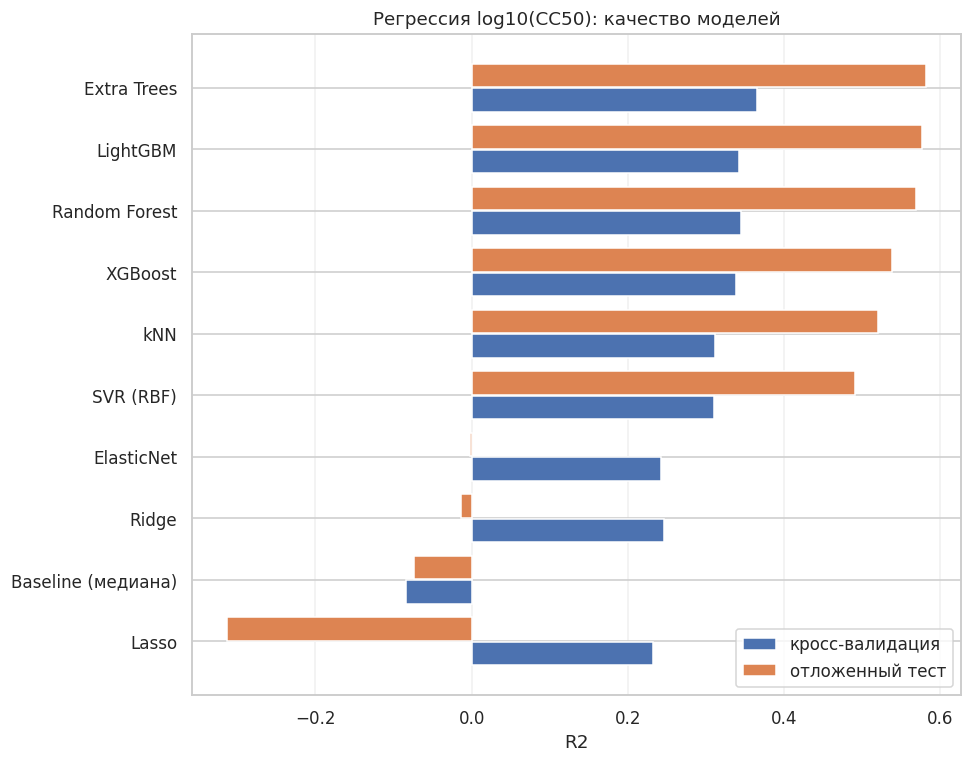

In [7]:
mdl.plot_cv_vs_test(
    cv_table, test_table, "CV r2", "R2",
    "Регрессия log10(CC50): качество моделей",
    save_path=FIG_DIR / "cc50_reg_models_comparison.png",
)

## 5. Диагностика лучшей модели

Три графика отвечают на  вопросы: есть ли систематическое смещение прогноза, однородна ли ошибка по диапазону значений, нормальны ли остатки

Лучшая модель на тесте: Extra Trees


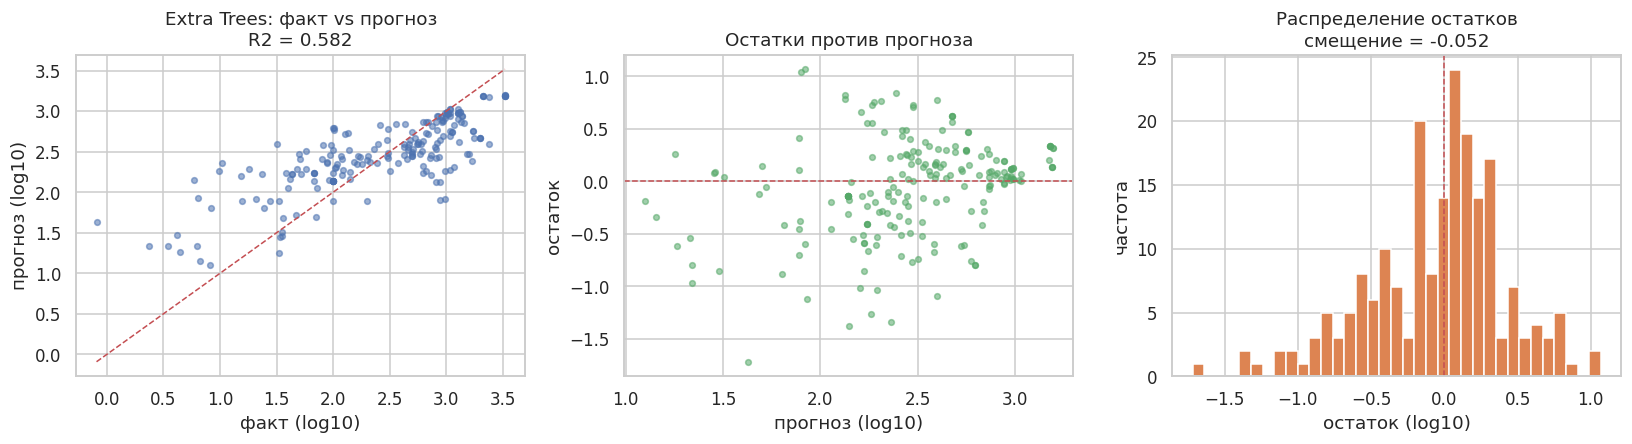

In [8]:
best_name = test_table.iloc[0]["модель"]
best_model = fitted[best_name]
print(f"Лучшая модель на тесте: {best_name}")

predictions = best_model.predict(X_test)
mdl.plot_regression_diagnostics(
    y_test.to_numpy(), predictions, best_name,
    save_path=FIG_DIR / "cc50_reg_diagnostics.png",
)

In [9]:
errors = pd.DataFrame({
    "факт": y_test.to_numpy(),
    "прогноз": predictions,
    "остаток": y_test.to_numpy() - predictions,
})
quartiles = pd.qcut(errors["факт"], 4,
                    labels=["Q1 (низкие)", "Q2", "Q3", "Q4 (высокие)"])
print("Средний остаток и MAE по квартилям истинного значения:")
display(errors.groupby(quartiles)["остаток"].agg(
    смещение="mean", MAE=lambda s: s.abs().mean(), объектов="size").round(3))

Средний остаток и MAE по квартилям истинного значения:


,смещение,MAE,объектов
факт,,,
Q1 (низкие),-0.573,0.597,51
Q2,-0.193,0.246,51
Q3,0.254,0.263,50
Q4 (высокие),0.311,0.311,51


## 6. дескрипторы определяющие прогноз

Используется permutation importance на отложенном тесте: признак перемешивается и измеряеться падение R^2

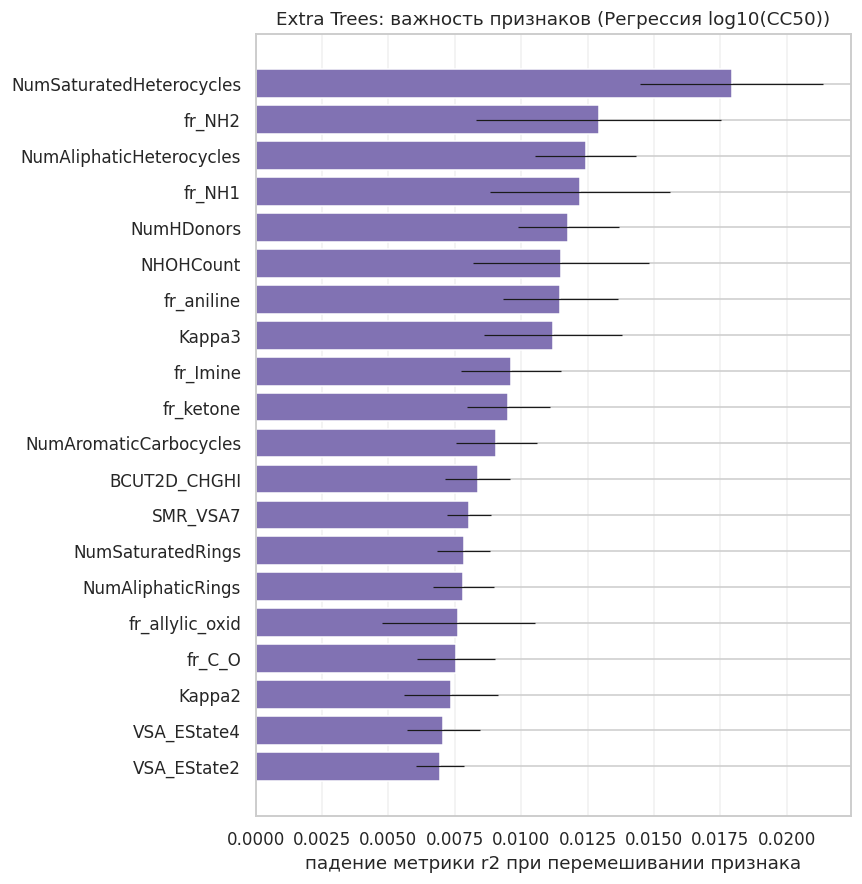

,признак,падение качества,std
0,NumSaturatedHeterocycles,0.0179,0.0034
1,fr_NH2,0.0129,0.0046
2,NumAliphaticHeterocycles,0.0124,0.0019
3,fr_NH1,0.0122,0.0034
4,NumHDonors,0.0118,0.0019
5,NHOHCount,0.0115,0.0033
6,fr_aniline,0.0115,0.0022
7,Kappa3,0.0112,0.0026
8,fr_Imine,0.0096,0.0019
9,fr_ketone,0.0095,0.0016


In [ ]:
importance = mdl.plot_permutation_importance(
    best_model, X_test, y_test, scoring="r2",
    title=f"{best_name}: важность признаков (Регрессия log10(CC50))",
    save_path=FIG_DIR / "cc50_reg_importance.png",
)
display(importance.head(15).round(4))
importance.to_csv(RES_DIR / "cc50_reg_importance.csv", index=False)

## 7. Устойчивость результата

Одно разбиение train/test даёт лишь точечную оценку. Повторяем обучение и измерение на пяти независимых групповых разбиениях, чтобы понять, насколько приведённые цифры воспроизводимы

In [11]:
from sklearn.metrics import r2_score

stability = mdl.stability_check(
    best_model, features, target, groups,
    scoring=lambda y_true, model, X: r2_score(y_true, model.predict(X)),
)
display(stability.round(4))

Среднее = 0.3957, std = 0.0973, размах = 0.2267


,seed,метрика
0,0,0.2878
1,1,0.4665
2,2,0.5145
3,3,0.3117
4,4,0.3982


## 8. Выводы по задаче регрессии CC50
(красивую табилцу попросил у дипсика сделать , каюсь, зато приятнее для понимания) - как и во всех остальных ноутбуках 

### Что показали модели

| Наблюдение | Интерпретация |
|---|---|
| CC50 предсказывается **лучше всех трёх таргетов**: CV R² ≈ 0.37, на тесте ≈ 0.58 | Цитотоксичность сильнее связана с общими физико-химическими свойствами молекулы, чем специфическая противовирусная активность |
| Разрыв между линейными моделями и ансамблями здесь **меньше**, чем для IC50: Ridge даёт CV R² ≈ 0.25 против 0.37 у Extra Trees | В цитотоксичности есть заметная линейная составляющая. Это согласуется с EDA: наиболее коррелированные с CC50 признаки (`Kappa1-3`, `Chi`, `MolMR`, `LabuteASA`) — все дескрипторы размера и липофильности молекулы |
| Верхние строки занимают Extra Trees, LightGBM и Random Forest с разницей в пределах 0.01 | Модели упёрлись в общий информационный предел признакового пространства; дальнейший прирост даст не смена алгоритма, а новые признаки |
| Медианная ошибка — менее чем в 2 раза по концентрации | Наилучшая практическая точность среди трёх регрессий |

### Химическая интерпретация

Здесь важно различать два разных среза важности признаков, и их расхождение
само по себе содержательно.

корреляции Спирмена из EDA выводит на первый план размер и разветвлённость молекулы
Kappa1-3, Chi, MolMR, LabuteASA , "крупные липофильные молекулы хуже выводятся и чаще дают неспецифическую токсичность" Именно поэтому линейные модели так уверенно предсказывают CC50 и заметно хуже справляются с IC50

permutation importance лучшей модели выдает совершенно другую группу: число насыщенных гетероциклов, аминогруппы (fr_NH2, fr_NH1) и доноры водородных связей (NumHDonors, NHOHCount). Размерные дескрипторы сюда уже не попадают их вклад затерся линейной частью и размыт между десятками коррелированных признаков

Токсичность в основе это размер и липофильность, а все нюансы уже водородные связи, ансамбли деревьев как раз их и цепляют, отсюда и прирост R^2 с 0.25 до 0.37

### Рекомендация

В качестве основной выбираем Extra Trees. Модель работает точнее, чем для IC50, и её можно использовать как быстрый фильтр безопасности на ранних этапах отбора

### Улучшения

- **Структура** RDKit слишком общий. Добавьте отпечатки (Morgan, ECFP) или графовые сети  в QSAR это стандартно даёт буст.
- **Данные** 804 молекул маловато. Нужно подтянуть ChEMBL или PubChem по тому же вирусу.
